<a href="https://colab.research.google.com/github/LadyRhanes/concrete/blob/main/concrete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%pip install ydata-profiling
from ydata_profiling import ProfileReport
from matplotlib import cm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest,f_classif,f_regression
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
dataset='/content/ds.txt'
data=pd.read_csv(dataset)
data.head()



,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


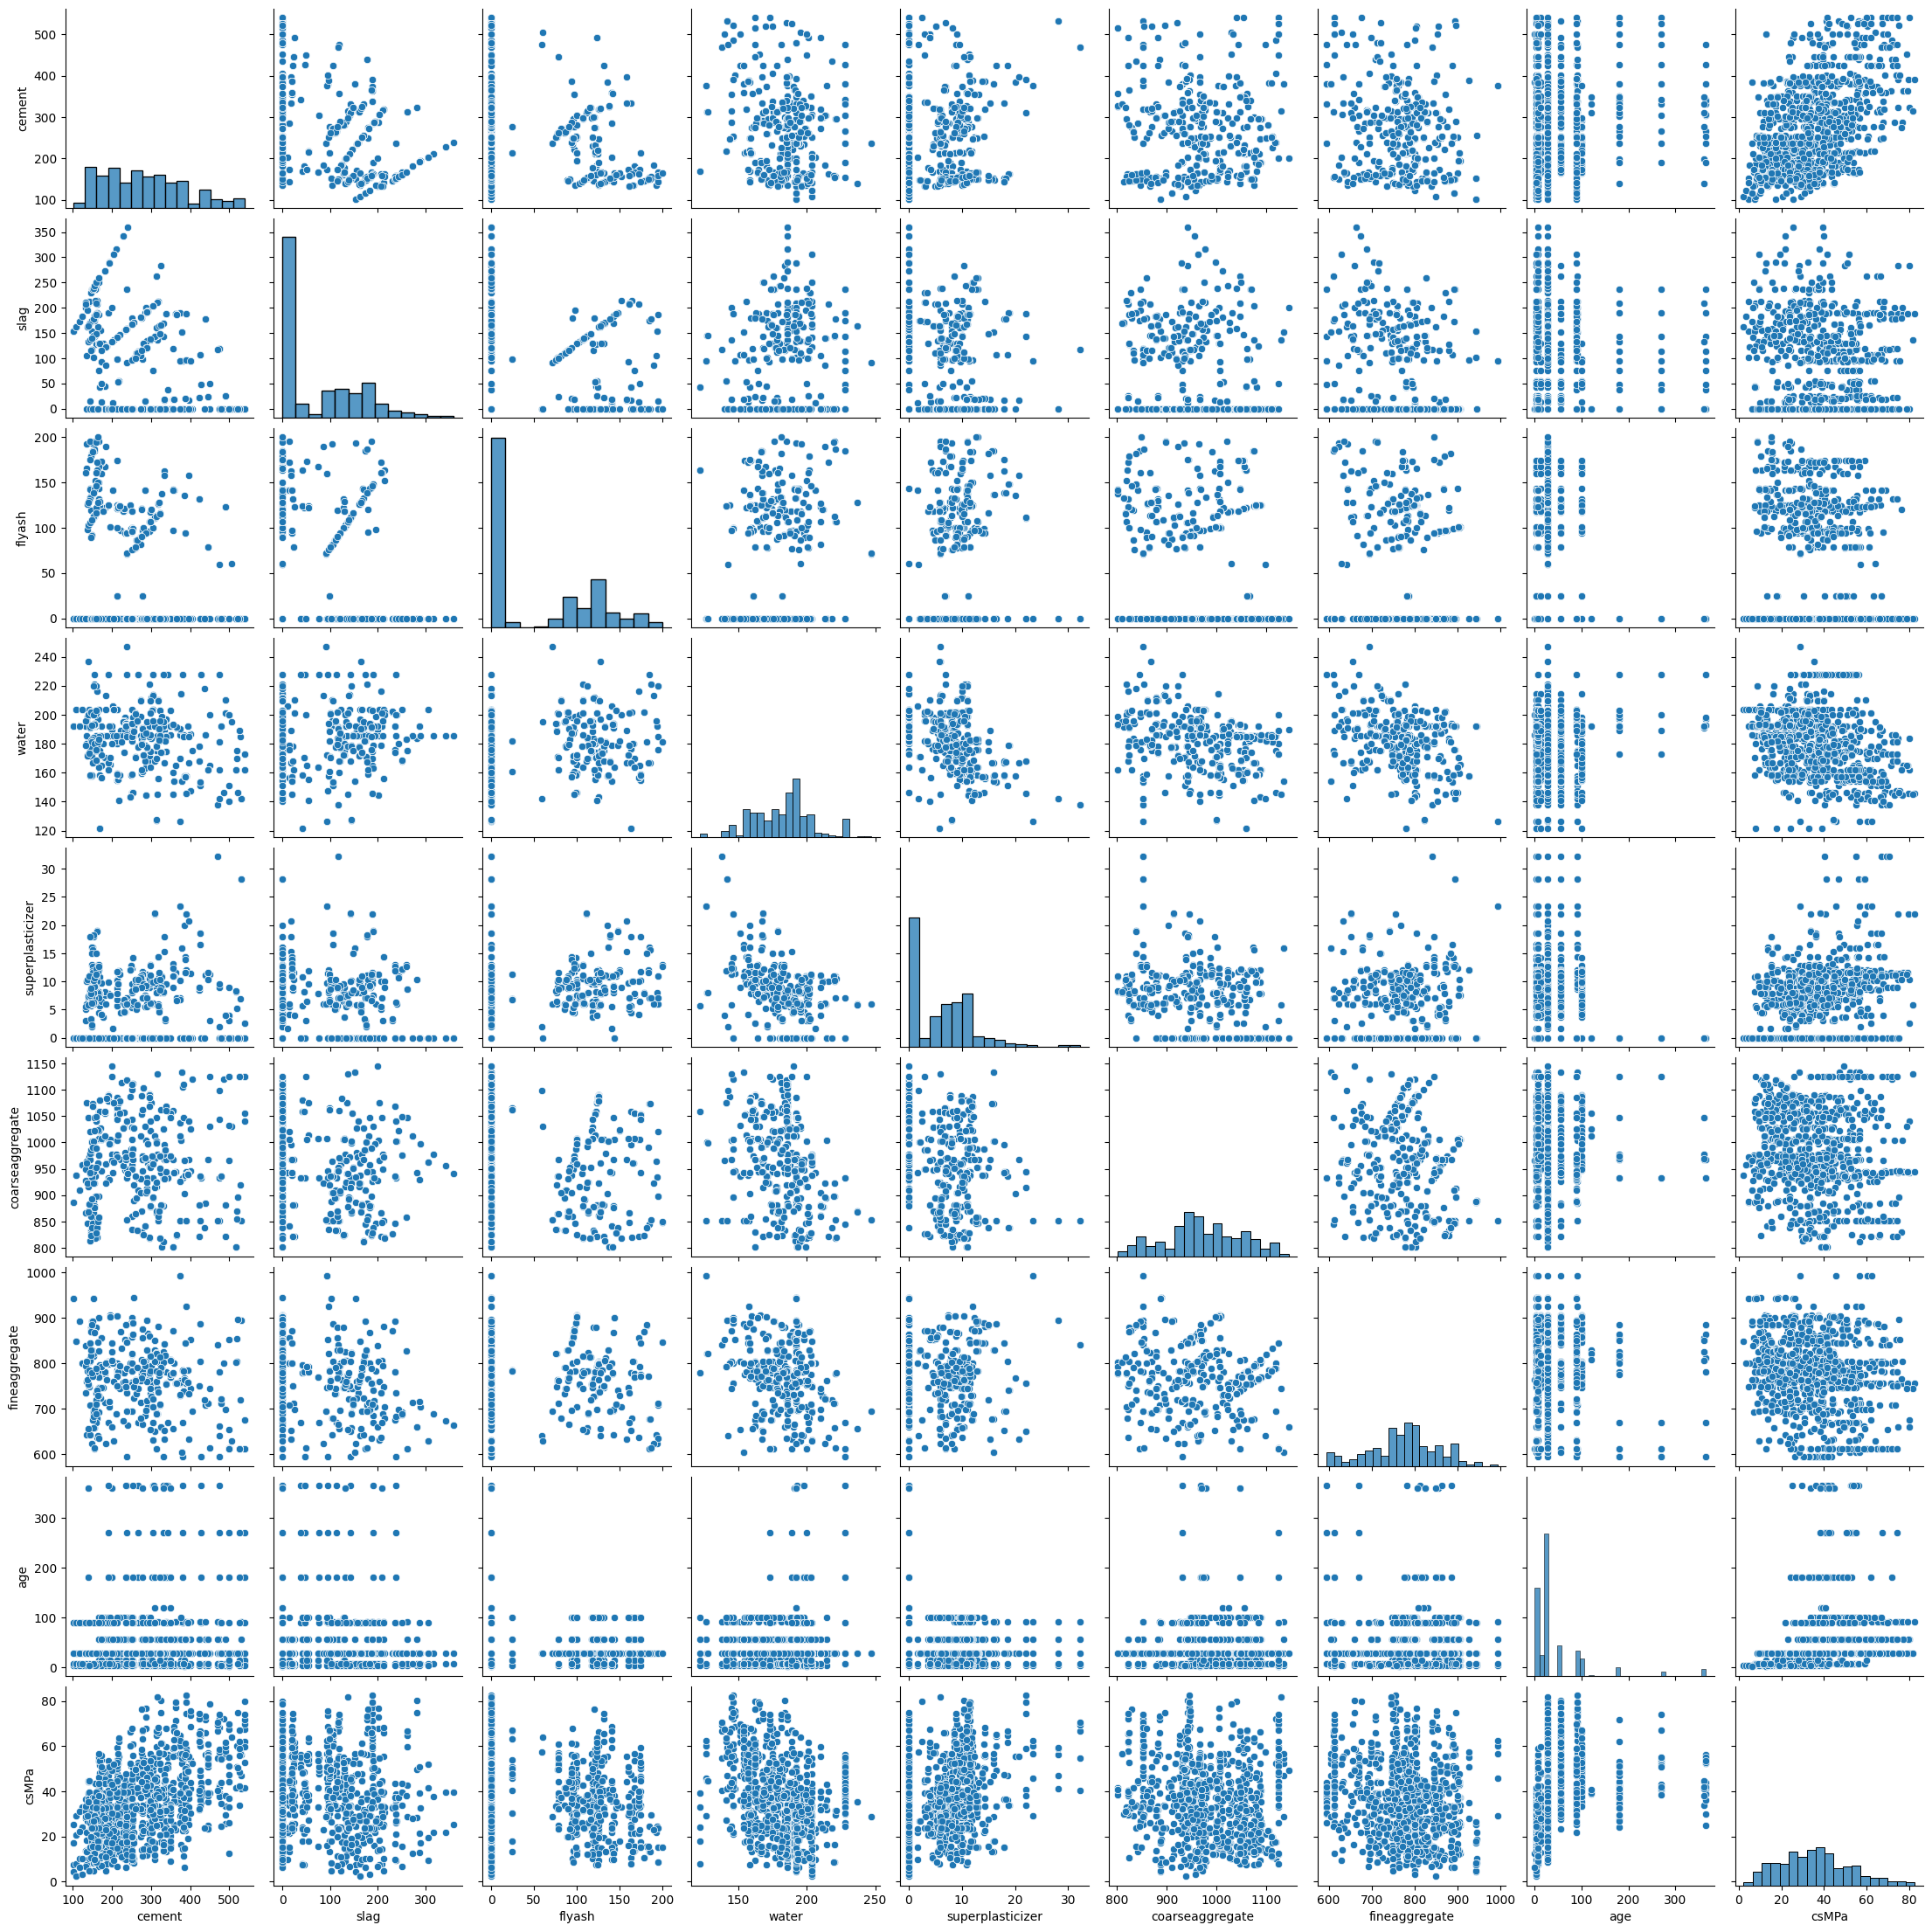

In [ ]:
sns.pairplot(data)

In [ ]:
data['strength']=np.where(data['csMPa']>=44 ,'high','low')
data.head()


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,high
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,high
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,low
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,low
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,high


In [ ]:
data.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [ ]:
profile=ProfileReport(data,explorative=True ,minimal= True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 106.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
data['strength'].value_counts()

,count
strength,
low,736
high,294


<BarContainer object of 2 artists>

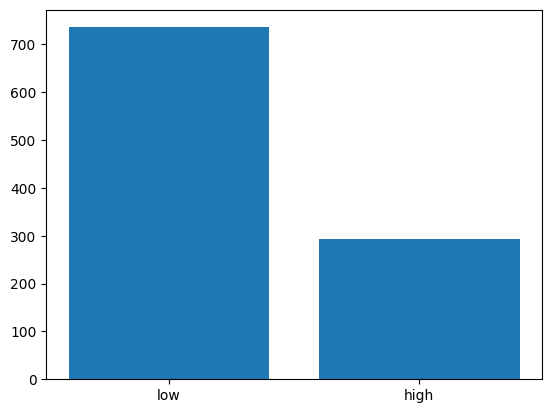

In [ ]:
plt.bar(x=['low','high'],height=data['strength'].value_counts())

In [ ]:
data.strength=[1 if x=='high' else 0 for x in data.strength ]
data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,1
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,1
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,1


,0
cement,"Axes(0.125,0.53;0.133621x0.35)"
slag,"Axes(0.285345,0.53;0.133621x0.35)"
flyash,"Axes(0.44569,0.53;0.133621x0.35)"
water,"Axes(0.606034,0.53;0.133621x0.35)"
superplasticizer,"Axes(0.766379,0.53;0.133621x0.35)"
coarseaggregate,"Axes(0.125,0.11;0.133621x0.35)"
fineaggregate,"Axes(0.285345,0.11;0.133621x0.35)"
age,"Axes(0.44569,0.11;0.133621x0.35)"
csMPa,"Axes(0.606034,0.11;0.133621x0.35)"
strength,"Axes(0.766379,0.11;0.133621x0.35)"


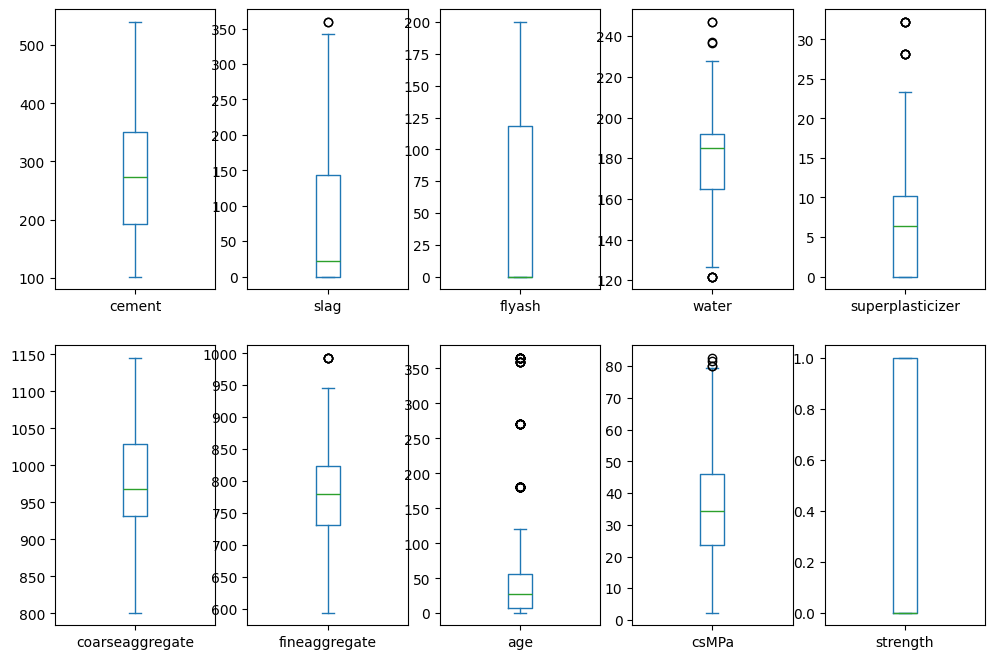

In [ ]:
data.plot(kind='box',subplots=True,layout=(2,5),figsize=(12,8))